# Demo to use the Stretcher object

### A test to show that the stretcher works exactly the same way for positive/negative times
Thus the same approch can be used for two-sided correlation functions.  
See jupyter notbook named "examples" for details.  

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal.windows import tukey
from scipy.signal import butter, sosfiltfilt

from coodddaaaa.stretching import Stretcher # This package
from coodddaaaa.utils import Timer, polyspace, TukeyWindow # This package

In [2]:
dt = 1e-7  # sampling, sec
nt = int(5e-4 // dt)   # number of samples in time
t0 = -2.5e-4   # start time in sec

time_array = t0 + np.arange(nt) * dt  # seconds  (NEVER use np.linspace for time vectors)
fnyquist = 0.5 / dt    # Hz

tmin = 0.1e-4   # begin of time window in sec
tmax = 2.4e-4   # end of time window in sec
fmin = 0.01 * fnyquist   # lower freq Hz
fmax = 0.05 * fnyquist   # upper freq Hz

eps_true = 0.02  # the imposed stretching coeff

In [3]:
# create the time taper
tukeywin = TukeyWindow(tmin-0.01*nt*dt, tmin, tmax, tmax+0.01*nt*dt)
taper = tukeywin(time_array) + tukeywin(-time_array)

# and the bandpass filter
sos = butter(4.0, [fmin / fnyquist, fmax / fnyquist], output="sos", btype="band")  # for 
bandpass = lambda signal_array: sosfiltfilt(sos, signal_array)  # predefined bandpass filter

In [4]:
# Build the reference band-pass / tapered coda
y_reference = bandpass(np.random.randn(nt)) * taper


In [5]:
# Build the observed signal, a stretched version of it + noise
stretcher0 = Stretcher(t0=t0, nt=nt, dt=dt, eps=np.array([eps_true]), norm=False)  # for stretching only
y_observed = stretcher0.stretch(y_reference)[0, :]  # only one trace here

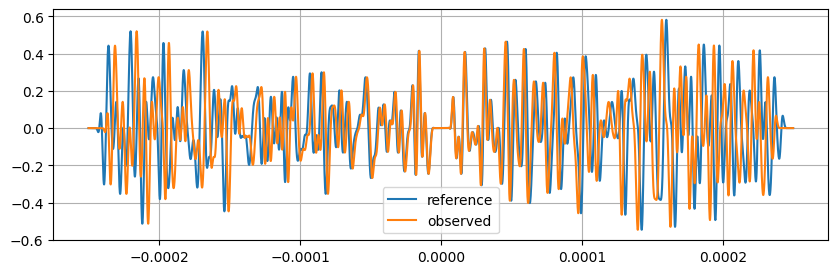

In [6]:
# Display
plt.figure(figsize=(10, 3))
plt.plot(time_array, y_reference, label="reference")
plt.plot(time_array, y_observed, label="observed");
plt.gca().legend();
plt.gca().grid(True)